In [ ]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.special import j1
from scipy.ndimage import shift as ndshift
import matplotlib.pyplot as plt

# ── camera sensor ──────────────────────────────────────────────────────────
H, W       = 256, 256   # camera frame [sensor pixels]
FWC        = 1e4        # full-well capacity [electrons]
RN         = 2.0        # readout noise sigma [ADC]
BIAS       = 0.0        # bias level [ADC]

# ── PSF sub-pixel model ────────────────────────────────────────────────────
R_AIRY_PX  = 1.0        # Airy first-dark-ring radius [camera pixels]
PSF_FINE   = 128        # fine-grid size for PSF [fine pixels, square]
OVERSAMPLE = 32         # fine pixels per camera pixel
#   PSF_FINE / OVERSAMPLE = 4×4 camera-pixel footprint per defect

# ── jitter interface (fine pixels) ────────────────────────────────────────
JITTER_MAX_SPX = OVERSAMPLE   # ±1 camera pixel max; reserved for future use

In [129]:
# ══════════════════════════════════════════════════════════════════════════
# Module 1 — PSF model
#
# Airy disk on PSF_FINE×PSF_FINE fine grid → bin OVERSAMPLE×OVERSAMPLE
# → (PSF_FINE//OVERSAMPLE)² camera-pixel footprint.
#
# With PSF_FINE=128, OVERSAMPLE=32 → 4×4 footprint.
# Airy main lobe stays in central 2×2; secondary rings fill outer 4×4.
# ══════════════════════════════════════════════════════════════════════════

class PSF:
    def __init__(self, r_airy_px=R_AIRY_PX, psf_fine=PSF_FINE, oversample=OVERSAMPLE):
        self.r_airy_px  = r_airy_px
        self.psf_fine   = psf_fine
        self.oversample = oversample

    @staticmethod
    def _bin2d(img, factor):
        H, W = img.shape
        H2, W2 = H // factor, W // factor
        return (img[:H2*factor, :W2*factor]
                .reshape(H2, factor, W2, factor)
                .sum(axis=(1, 3)))

    def make_fine(self, jitter_spx=0.0):
        """Airy PSF on psf_fine×psf_fine fine grid, normalised to sum=1."""
        half = self.psf_fine // 2
        y, x = np.mgrid[-half:half, -half:half].astype(float)
        r = np.sqrt(x**2 + y**2)
        u = 3.8317 * r / (self.r_airy_px * self.oversample)
        k = np.where(r == 0, 1.0, (2.0 * j1(u) / u)**2)
        k /= k.sum()
        if jitter_spx != 0.0:
            k = ndshift(k, (0.0, jitter_spx), order=3, mode='constant', cval=0.0)
        return k

    def make_template(self, A=1.0, jitter_spx=0.0):
        """Camera-pixel PSF: shape (psf_fine//oversample)². Values sum to A."""
        return self._bin2d(self.make_fine(jitter_spx), self.oversample) * A

    def stamp(self, frame, x_px, y_px, A=1.0, jitter_spx=0.0):
        """Add defect PSF centred at (x_px, y_px) into frame (in-place)."""
        tmpl = self.make_template(A, jitter_spx)
        th, tw = tmpl.shape
        r0, c0 = y_px - th // 2, x_px - tw // 2
        r1, c1 = r0 + th, c0 + tw
        if r0 >= 0 and c0 >= 0 and r1 <= frame.shape[0] and c1 <= frame.shape[1]:
            frame[r0:r1, c0:c1] += tmpl


# ── sanity check ──────────────────────────────────────────────────────────
psf = PSF()
_t  = psf.make_template(A=100.0)
_sz = PSF_FINE // OVERSAMPLE
print(f"Fine grid   : {PSF_FINE}×{PSF_FINE}  OVERSAMPLE={OVERSAMPLE}")
print(f"Camera PSF  : {_t.shape}  sum={_t.sum():.2f} e-")
print(f"Central 2×2 : {_t[_sz//2-1:_sz//2+1, _sz//2-1:_sz//2+1].sum():.2f} e-  "
      f"({_t[_sz//2-1:_sz//2+1, _sz//2-1:_sz//2+1].sum()/_t.sum()*100:.1f}%)")
print(_t)

Fine grid   : 128×128  OVERSAMPLE=32
Camera PSF  : (4, 4)  sum=100.00 e-
Central 2×2 : 91.49 e-  (91.5%)
[[ 0.31275184  0.88696613  0.89831264  0.32474447]
 [ 0.88696613 21.22240816 22.84037603  0.90576881]
 [ 0.89831264 22.84037603 24.58395142  0.91536214]
 [ 0.32474447  0.90576881  0.91536214  0.33782815]]


C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\2407881578.py:31: RuntimeWarning: invalid value encountered in divide
  k = np.where(r == 0, 1.0, (2.0 * j1(u) / u)**2)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Module 3 — Background noise model
# ══════════════════════════════════════════════════════════════════════════

class Background:
    def __init__(self, H=H, W=W, rn=RN, bias=BIAS, rng=None):
        self.H    = H
        self.W    = W
        self.rn   = rn
        self.bias = bias
        self.rng  = rng if rng is not None else np.random.RandomState()

    def readout_noise(self):
        """Gaussian readout noise ~ N(bias, rn²)."""
        return self.bias + self.rng.normal(0.0, self.rn, size=(self.H, self.W))

    # def poisson_noise(self, flux_map): ...   # future
    # def speckle_noise(self, sigma): ...      # future

    def sample(self):
        """Combined background frame (all active noise sources)."""
        return self.readout_noise()

    def create_figure(self, figsize=(8, 6), layout='horizontal'):
        if layout == 'horizontal':
            fig, axes = plt.subplots(1, 2, figsize=figsize,
                                     gridspec_kw={'width_ratios': [4, 1]})
        elif layout == 'vertical':
            fig, axes = plt.subplots(2, 1, figsize=figsize,
                                     gridspec_kw={'height_ratios': [4, 1]})
        else:
            raise ValueError("layout must be 'horizontal' or 'vertical'")
        return fig, axes

    def draw(self, axes, frame, title='', defects=None):
        ax_img, ax_hist = axes[0], axes[1]
        vmax = max(np.percentile(frame, 99.9), 3 * self.rn)
        im = ax_img.imshow(frame, cmap='gray', interpolation='nearest',
                           vmin=self.bias - 3 * self.rn, vmax=vmax, aspect='auto')
        if defects:
            for (xd, yd, _) in defects:
                ax_img.plot(xd, yd, 'c+', ms=8, mew=1.2)
        ax_img.set_title(title)
        plt.colorbar(im, ax=ax_img, label='ADC')
        ax_hist.hist(frame.ravel(), bins=100, density=True,
                     color='steelblue', alpha=0.7, orientation='horizontal')
        xg = np.linspace(frame.min(), frame.max(), 300)
        ax_hist.plot(
            np.exp(-0.5 * ((xg - self.bias) / self.rn)**2) / (self.rn * np.sqrt(2 * np.pi)),
            xg, 'r-', lw=1.5, label=f'N({self.bias},{self.rn}²)')
        ax_hist.set_xlabel('density'); ax_hist.legend(fontsize=8); ax_hist.grid(True)

    def plot(self, frame, title='', defects=None, layout='horizontal', figsize=(8, 6)):
        fig, axes = self.create_figure(figsize=figsize, layout=layout)
        self.draw(axes, frame, title, defects)
        plt.tight_layout()
        return fig, axes

### image lag kernel 
根据lag_model 拟合后的参数带入

In [154]:
import numpy as np
from scipy.signal import fftconvolve


class ImageLag:
    """
    Hammerstein image-lag forward model.

        r(t, Q) = [Q − f(Q)] · δ(t=0) + f(Q) · h(t)

    其中:
        f(Q)  = Nt · (1 − exp(−Q/Qc))     per-pixel 静态非线性 (陷阱填充)
        h(τ)  = (1−α) · α^(τ−1), τ=1..T   归一化释放核 (沿 x 拖尾, Σh=1)

    标定来源:
        Nt, Qc : 多 Q (30/?/?) 拟合,  R²=0.996
        α      : Q=30 单点拟合, h(t) 假设与 Q 无关 (Hammerstein)
    """

    # ── 默认标定参数 ─────────────────────────────────────────────────
    NT_DEFAULT    = 62.63     # 陷阱容量上限 [DN]
    QC_DEFAULT    = 85.4      # 半饱和信号    [DN]
    ALPHA_DEFAULT = 0.656     # 单帧保留比例
    LEN_DEFAULT   = 13        # 拖尾长度 (帧)

    def __init__(self,
                 Nt=NT_DEFAULT,
                 Qc=QC_DEFAULT,
                 alpha=ALPHA_DEFAULT,
                 T=LEN_DEFAULT):
        self.Nt    = Nt
        self.Qc    = Qc
        self.alpha = alpha
        self.T     = T
        self._kernel_cache = None        # 释放核缓存

    # ── 派生量 (只读属性) ────────────────────────────────────────────
    @property
    def k(self):
        """衰减率 k = −ln(α)"""
        return -np.log(self.alpha)

    @property
    def tau_e(self):
        """1/e 时间常数 (帧) = 1/k"""
        return 1.0 / self.k

    @property
    def t_half(self):
        """半衰期 (帧) = ln2 / k"""
        return np.log(2) / self.k

    @property
    def lag_cap(self):
        """单像素 lag 任一帧的硬上限 = Nt·(1−α)"""
        return self.Nt * (1 - self.alpha)

    # ── 静态非线性 f(Q) ──────────────────────────────────────────────
    def f_trap(self, Q):
        """Per-pixel 静态非线性: 被陷阱抓走的电荷 (向量化, 任意形状)"""
        return self.Nt * (1.0 - np.exp(-np.clip(Q, 0, None) / self.Qc))

    def remaining(self, Q):
        """当帧读出 = Q − f(Q)"""
        return Q - self.f_trap(Q)

    # ── 释放核 h(τ) ──────────────────────────────────────────────────
    def kernel(self):
        """归一化释放核 [0, h(1), ..., h(T)] 作为 1×(T+1) 行向量.
        前补 0 → 拖尾从下一像素 (x+1) 开始, 当帧不产生 lag."""
        if self._kernel_cache is None:
            t = np.arange(1, self.T + 1)
            h = (1.0 - self.alpha) * self.alpha ** (t - 1)
            self._kernel_cache = np.concatenate([[0.0], h]).reshape(1, -1)
        return self._kernel_cache

    # ── 2D forward model ────────────────────────────────────────────
    def apply(self, frame, return_parts=False):
        """
        把 image lag 加到整张 clean frame 上.

        Parameters
        ----------
        frame : (H, W) ndarray
            清洁 PSF 信号图 (尚未加 lag, 尚未加噪声).
        return_parts : bool
            True  → 返回 (out, trapped, remaining, lag) 调试用.
            False → 只返回 out.

        Returns
        -------
        out : (H, W) ndarray
            含 lag 的输出图 (尚未加噪声).
        """
        H, W = frame.shape
        trapped   = self.f_trap(frame)
        remaining = frame - trapped
        h_kernel  = self.kernel()
        lag       = fftconvolve(trapped, h_kernel, mode='full')[:H, :W]
        out       = remaining + lag
        if return_parts:
            return out, trapped, remaining, lag
        return out

    # ── 标量预测 (单像素冲激响应, 用于核对实测) ─────────────────────
    def predict(self, Q, t_max=None):
        """
        单像素接受 Q DN 输入时, 沿 x 各帧理论值.
        返回 dict: {'peak', 'lag', 'fQ', 'sum'}
            peak     : 当帧读出 = Q − f(Q)
            lag      : 长度 T 的数组, lag[τ-1] = f(Q)·h(τ)
            fQ       : f(Q)
            sum      : peak + Σlag (应严格等于 Q, 用于核对)
        """
        T = self.T if t_max is None else t_max
        fQ = self.f_trap(Q)
        t  = np.arange(1, T + 1)
        lag = fQ * (1 - self.alpha) * self.alpha ** (t - 1)
        return {
            'peak': Q - fQ,
            'lag':  lag,
            'fQ':   fQ,
            'sum':  Q - fQ + lag.sum(),
        }

    # ── 参数热更新 ───────────────────────────────────────────────────
    def update(self, **kwargs):
        """更新标定参数 (Nt, Qc, alpha, T 中任意几个), 自动失效缓存."""
        for k, v in kwargs.items():
            if not hasattr(self, k):
                raise KeyError(f"未知参数: {k}")
            setattr(self, k, v)
        self._kernel_cache = None        # 参数变了, 缓存作废
        return self                       # 链式调用

    # ── 友好打印 ─────────────────────────────────────────────────────
    def __repr__(self):
        return (f"ImageLag(Nt={self.Nt:.2f}, Qc={self.Qc:.2f}, "
                f"α={self.alpha:.4f}, T={self.T})\n"
                f"  k = {self.k:.4f},  τ_e = {self.tau_e:.2f} 帧,  "
                f"t_½ = {self.t_half:.2f} 帧,  lag_cap = {self.lag_cap:.2f} DN")

#### show psf output

C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\2407881578.py:31: RuntimeWarning: invalid value encountered in divide
  k = np.where(r == 0, 1.0, (2.0 * j1(u) / u)**2)


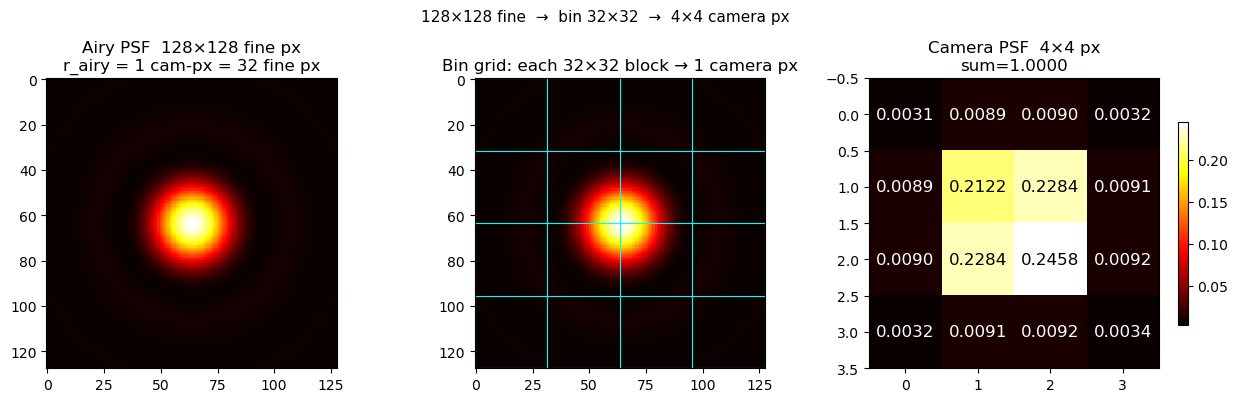

In [132]:
# ── visualise PSF pipeline ─────────────────────────────────────────────────
jitter_spx = 0   # sub-pixel shift to visualise

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

k_fine = psf.make_fine(jitter_spx=jitter_spx)
tmpl   = psf.make_template(A=1.0, jitter_spx=jitter_spx)

ax = axes[0]
ax.imshow(k_fine, cmap='hot', interpolation='nearest')
ax.set_title(f'Airy PSF  {psf.psf_fine}×{psf.psf_fine} fine px\n'
             f'r_airy = {psf.r_airy_px} cam-px = {psf.r_airy_px*psf.oversample:.0f} fine px')

ax = axes[1]
ax.imshow(k_fine, cmap='hot', interpolation='nearest')
for i in range(0, psf.psf_fine + 1, psf.oversample):
    ax.axhline(i - 0.5, color='cyan', lw=0.8)
    ax.axvline(i - 0.5, color='cyan', lw=0.8)
ax.set_title(f'Bin grid: each {psf.oversample}×{psf.oversample} block → 1 camera px')

ax = axes[2]
im = ax.imshow(tmpl, cmap='hot', interpolation='nearest')
for i in range(tmpl.shape[0]):
    for j in range(tmpl.shape[1]):
        ax.text(j, i, f'{tmpl[i,j]:.4f}', ha='center', va='center',
                fontsize=12, color='black' if tmpl[i,j] > tmpl.max()*0.6 else 'white')
ax.set_title(f'Camera PSF  {tmpl.shape[0]}×{tmpl.shape[1]} px\nsum={tmpl.sum():.4f}')
fig.colorbar(im, ax=ax, shrink=0.7)

n_cam = psf.psf_fine // psf.oversample
fig.suptitle(f'{psf.psf_fine}×{psf.psf_fine} fine  →  bin {psf.oversample}×{psf.oversample}'
             f'  →  {n_cam}×{n_cam} camera px', fontsize=11)
plt.tight_layout()
plt.show()

### imagelag convolve psf test




C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\2407881578.py:31: RuntimeWarning: invalid value encountered in divide
  k = np.where(r == 0, 1.0, (2.0 * j1(u) / u)**2)
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Gl

PSF : r_airy=1, fine=128, OS=32
Lag : ImageLag(Nt=62.63, Qc=85.40, α=0.6560, T=13)
  k = 0.4216,  τ_e = 2.37 帧,  t_½ = 1.64 帧,  lag_cap = 21.54 DN
     k=0.4216, τ_e=2.37, t_½=1.64, lag_cap=21.54 DN

Camera PSF: 4×4, sum=100.00, max=24.58

电荷守恒: Σin = 100.00, Σout = 99.73, 差 = +0.271 (0.271%)


C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 38519 (\N{CJK UNIFIED IDEOGRAPH-9677}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 38449 (\N{CJK UNIFIED IDEOGRAPH-9631}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: UserWarning: Glyph 25235 (\N{CJK UNIFIED IDEOGRAPH-6293}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\4222877637.py:117: Use


图已存: psf_lag_integrated.png


Font 'default' does not have a glyph for '\u91ca' [U+91ca], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u653e' [U+653e], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6838' [U+6838], substituting with a dummy symbol.


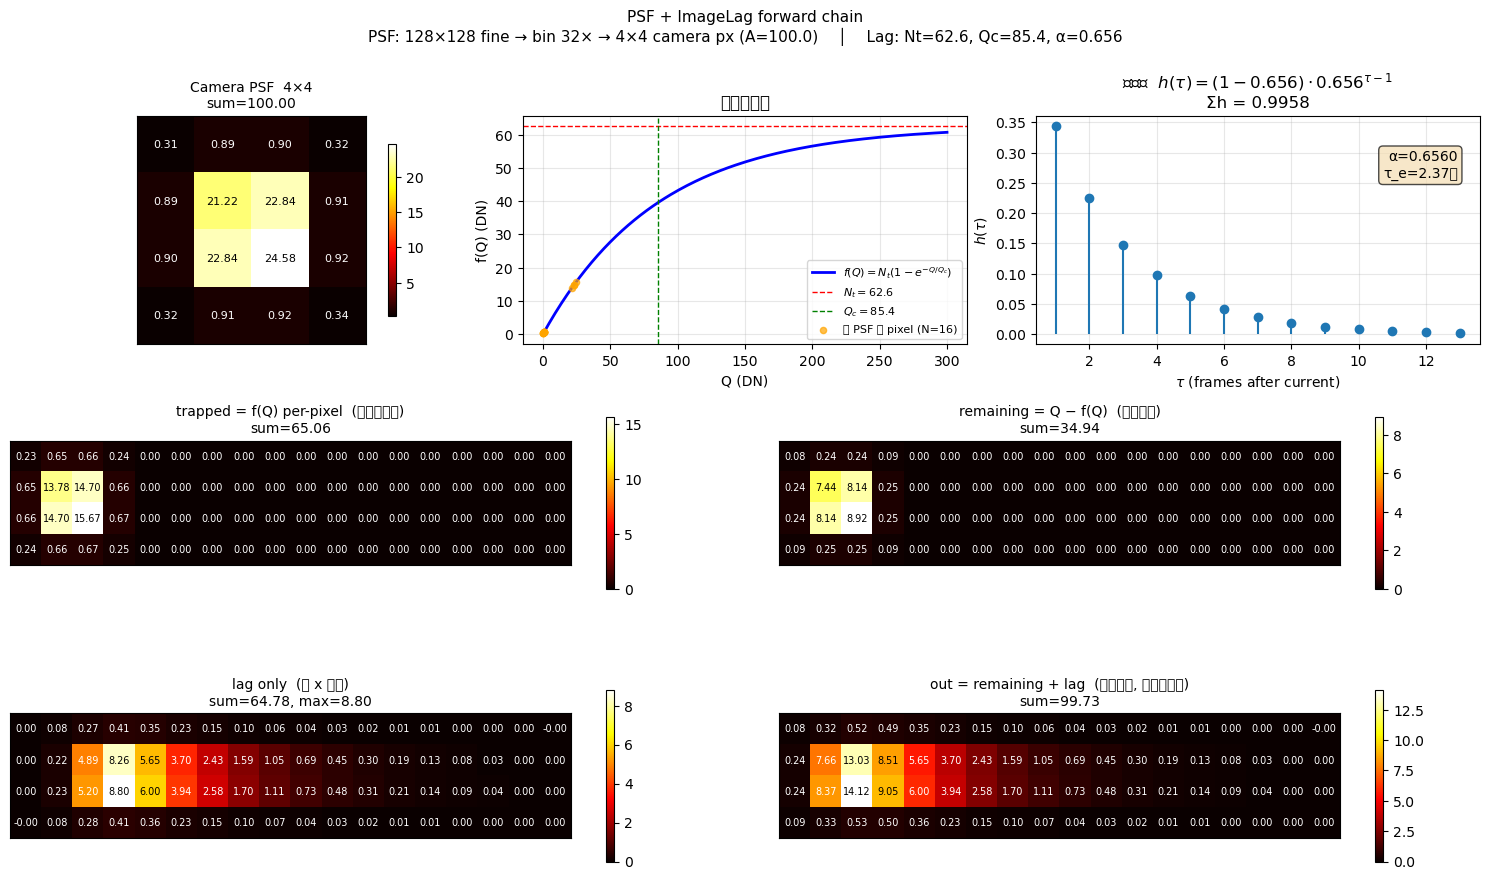

In [156]:
def annotated_heatmap(ax, arr, title, fmt='{:.2f}', cmap='hot', fontsize=8):
    """复用你提供的注解热图绘法."""
    im = ax.imshow(arr, cmap=cmap, interpolation='nearest')
    H, W = arr.shape
    threshold = arr.max() * 0.6 if arr.max() > 0 else 0.5
    for i in range(H):
        for j in range(W):
            ax.text(j, i, fmt.format(arr[i, j]),
                    ha='center', va='center',
                    fontsize=fontsize,
                    color='black' if arr[i, j] > threshold else 'white')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.75)
    return im


# ── 配置 ─────────────────────────────────────────────────────────
A          = 100.0    # defect 总亮度 (PSF 之和)
jitter_spx = 0.0      # 子像素抖动

psf = PSF()
lag = ImageLag()
print("PSF :", f"r_airy={psf.r_airy_px}, fine={psf.psf_fine}, OS={psf.oversample}")
print("Lag :", lag)
print(f"     k={lag.k:.4f}, τ_e={lag.tau_e:.2f}, t_½={lag.t_half:.2f}, "
      f"lag_cap={lag.lag_cap:.2f} DN")

# ── Step 1: 相机像素 PSF (你的原图) ─────────────────────────────
tmpl = psf.make_template(A=A, jitter_spx=jitter_spx)
th, tw = tmpl.shape
print(f"\nCamera PSF: {th}×{tw}, sum={tmpl.sum():.2f}, max={tmpl.max():.2f}")

# ── Step 2: 嵌入到 patch (右侧留 T+1 列给拖尾) ──────────────────
patch_w = tw + lag.T + 1
patch   = np.zeros((th, patch_w))
patch[:, :tw] = tmpl

# ── Step 3: 跑 lag forward ──────────────────────────────────────
out, trapped, remaining, lag_only = lag.apply(patch, return_parts=True)

# 守恒
sum_in, sum_out = patch.sum(), out.sum()
print(f"\n电荷守恒: Σin = {sum_in:.2f}, Σout = {sum_out:.2f}, "
      f"差 = {sum_in - sum_out:+.3f} ({(sum_in-sum_out)/sum_in*100:.3f}%)")


# ════════════════════════════════════════════════════════════════════
# 4) 绘图: 沿用你的注解热图风格
# ════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(15, 9))

# 左上: 原 camera PSF (正方, 跟你原图一样)
ax0 = plt.subplot2grid((3, 6), (0, 0), colspan=2)
annotated_heatmap(ax0, tmpl, f'Camera PSF  {th}×{tw}\nsum={tmpl.sum():.2f}',
                  fmt='{:.2f}', fontsize=8)

# 右上: 静态非线性曲线 f(Q)
ax1 = plt.subplot2grid((3, 6), (0, 2), colspan=2)
Qs = np.linspace(0, max(300, A*1.2), 200)
ax1.plot(Qs, lag.f_trap(Qs), 'b-', lw=2, label=r'$f(Q)=N_t(1-e^{-Q/Q_c})$')
ax1.axhline(lag.Nt, color='r', ls='--', lw=1, label=f'$N_t={lag.Nt:.1f}$')
ax1.axvline(lag.Qc, color='g', ls='--', lw=1, label=f'$Q_c={lag.Qc:.1f}$')
# 散点: 这次 PSF 各像素的 Q
qs_pix = tmpl.flatten()
fs_pix = lag.f_trap(qs_pix)
ax1.scatter(qs_pix, fs_pix, c='orange', s=20, alpha=0.7,
            label=f'此 PSF 各 pixel (N={len(qs_pix)})', zorder=5)
ax1.set_xlabel('Q (DN)'); ax1.set_ylabel('f(Q) (DN)')
ax1.set_title('静态非线性'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 右上: 释放核 h(τ)
ax2 = plt.subplot2grid((3, 6), (0, 4), colspan=2)
t_arr = np.arange(1, lag.T + 1)
h_arr = (1 - lag.alpha) * lag.alpha ** (t_arr - 1)
ax2.stem(t_arr, h_arr, basefmt=' ')
ax2.set_xlabel(r'$\tau$ (frames after current)'); ax2.set_ylabel(r'$h(\tau)$')
ax2.set_title(fr'释放核  $h(\tau)=(1-{lag.alpha:.3f})\cdot {lag.alpha:.3f}^{{\tau-1}}$'
              f'\nΣh = {h_arr.sum():.4f}')
ax2.grid(alpha=0.3)
ax2.text(0.95, 0.85, f'α={lag.alpha:.4f}\nτ_e={lag.tau_e:.2f}帧',
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 中行: trapped, remaining 各占 3 列
ax3 = plt.subplot2grid((3, 6), (1, 0), colspan=3)
annotated_heatmap(ax3, trapped,
                  f'trapped = f(Q) per-pixel  (被陷阱抓走)\nsum={trapped.sum():.2f}',
                  fmt='{:.2f}', fontsize=7)

ax4 = plt.subplot2grid((3, 6), (1, 3), colspan=3)
annotated_heatmap(ax4, remaining,
                  f'remaining = Q − f(Q)  (当帧读出)\nsum={remaining.sum():.2f}',
                  fmt='{:.2f}', fontsize=7)

# 底行: lag-only, out
ax5 = plt.subplot2grid((3, 6), (2, 0), colspan=3)
annotated_heatmap(ax5, lag_only,
                  f'lag only  (沿 x 拖尾)\nsum={lag_only.sum():.2f}, '
                  f'max={lag_only.max():.2f}',
                  fmt='{:.2f}', fontsize=7)

ax6 = plt.subplot2grid((3, 6), (2, 3), colspan=3)
annotated_heatmap(ax6, out,
                  f'out = remaining + lag  (最终输出, 尚未加噪声)\n'
                  f'sum={out.sum():.2f}',
                  fmt='{:.2f}', fontsize=7)

n_cam = psf.psf_fine // psf.oversample
fig.suptitle(
    f'PSF + ImageLag forward chain\n'
    f'PSF: {psf.psf_fine}×{psf.psf_fine} fine → bin {psf.oversample}× → '
    f'{n_cam}×{n_cam} camera px (A={A})    │    '
    f'Lag: Nt={lag.Nt:.1f}, Qc={lag.Qc:.1f}, α={lag.alpha:.3f}',
    fontsize=11, y=0.995)

plt.tight_layout()
plt.savefig('psf_lag_integrated.png', dpi=120, bbox_inches='tight')
print("\n图已存: psf_lag_integrated.png")


### background test

C:\Users\20250612\AppData\Local\Temp\ipykernel_16428\2407881578.py:31: RuntimeWarning: invalid value encountered in divide
  k = np.where(r == 0, 1.0, (2.0 * j1(u) / u)**2)


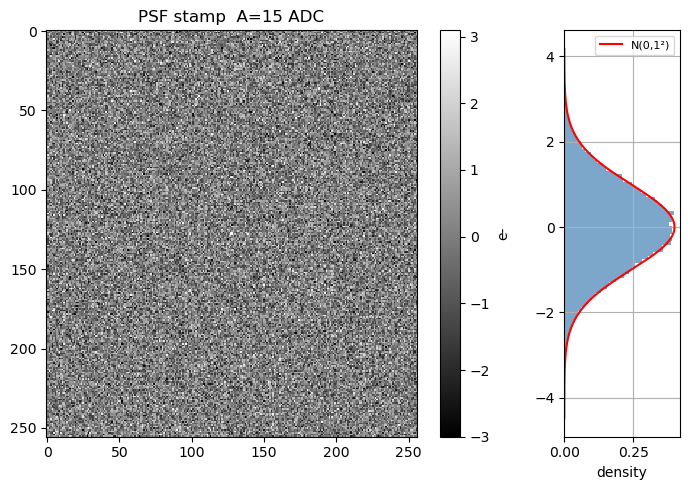

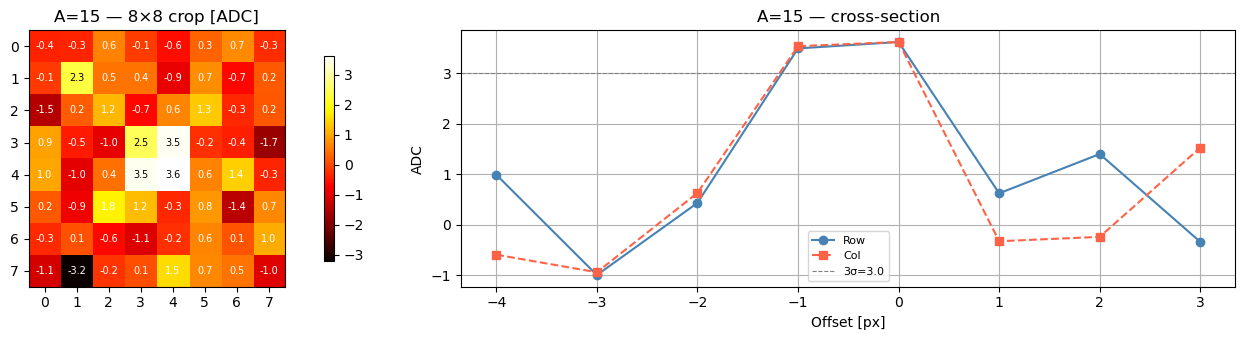

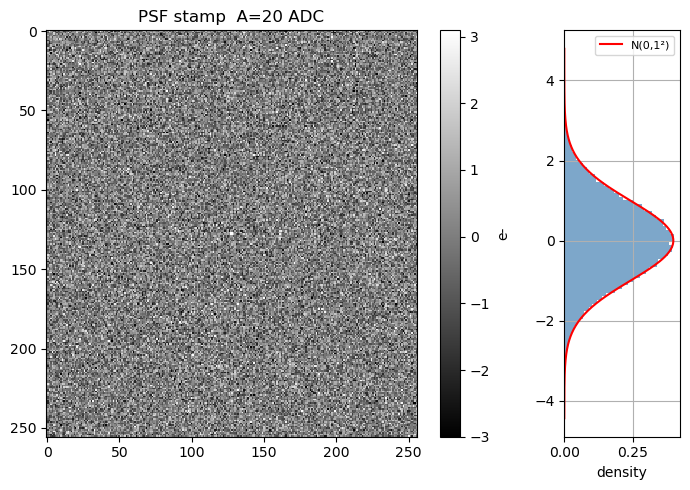

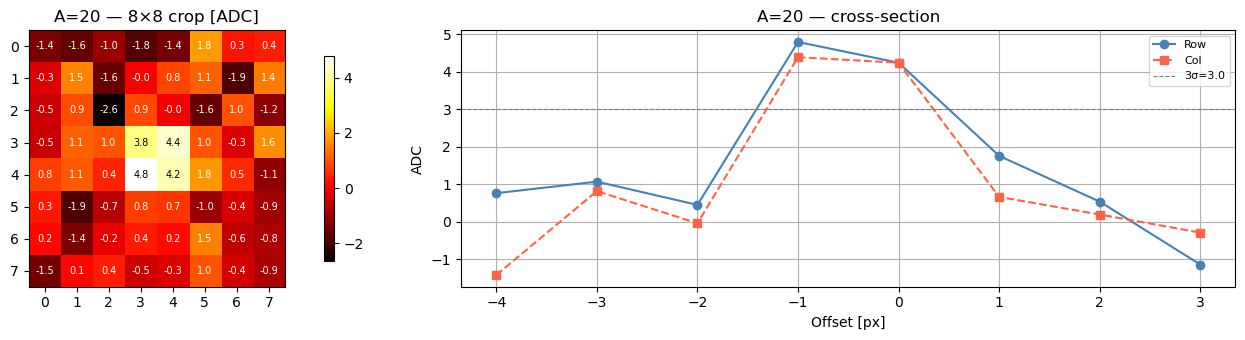

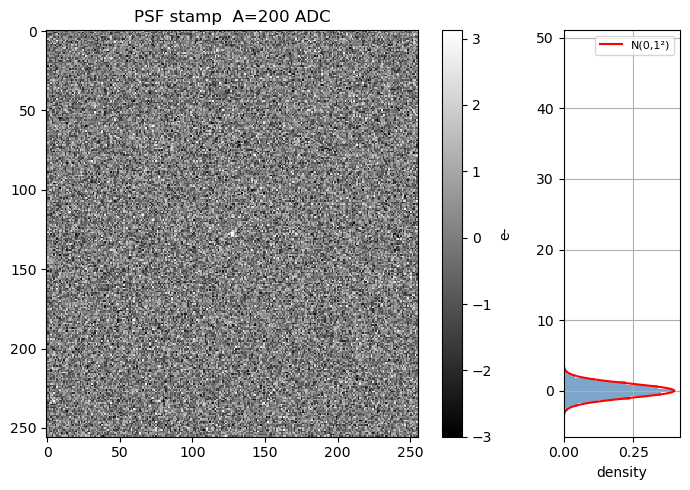

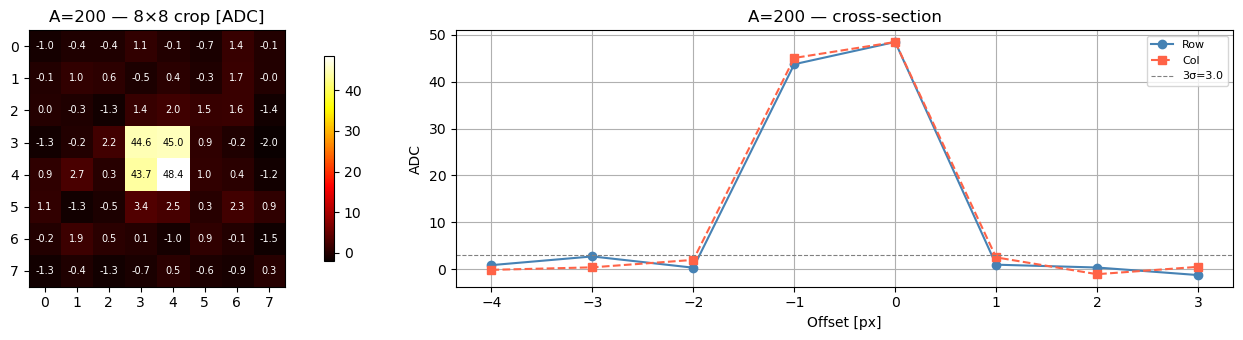

In [148]:
# ── PSF stamp on Background noise — 8×8 pixel intensity map ─────────────────
A_SHOW = [15, 20, 200]
cx, cy = W // 2, H // 2
half   = 4

for A in A_SHOW:
    bg    = Background(rn=1, bias=0)
    frame = bg.sample()
    psf.stamp(frame, cx, cy, A=A,jitter_spx=0)

    bg.plot(frame, title=f'PSF stamp  A={A} ADC', figsize=(7, 5))
    plt.show()

    crop = frame[cy-half:cy+half, cx-half:cx+half]
    fig, axes = plt.subplots(1, 2, figsize=(16, 3.5))

    ax = axes[0]
    im = ax.imshow(crop, cmap='hot', interpolation='nearest')
    ax.set_title(f'A={A} — 8×8 crop [ADC]')
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    for i in range(8):
        for j in range(8):
            v = crop[i, j]
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                    color='white' if v < crop.max() * 0.6 else 'black')

    ax2 = axes[1]
    px  = np.arange(8) - half
    ax2.plot(px, crop[half, :], 'o-',  color='steelblue', label='Row')
    ax2.plot(px, crop[:, half], 's--', color='tomato',    label='Col')
    ax2.axhline(3 * bg.rn, color='gray', lw=0.8, ls='--', label=f'3σ={3*bg.rn:.1f}')
    ax2.set_xlabel('Offset [px]'); ax2.set_ylabel('ADC')
    ax2.set_title(f'A={A} — cross-section'); ax2.legend(fontsize=8); ax2.grid(True)

    plt.tight_layout(); plt.show()

(<Figure size 800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Readout noise'}>,
        <Axes: xlabel='density'>], dtype=object))

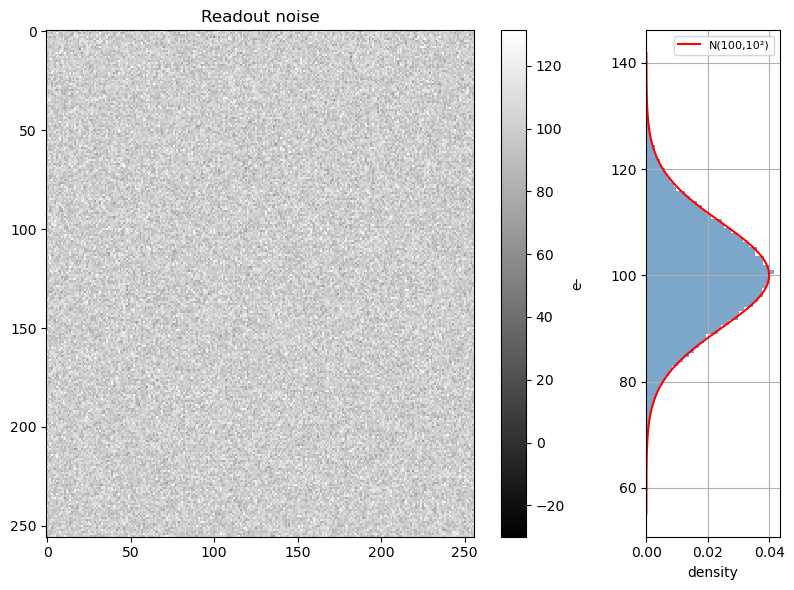

In [150]:
### example
bg = Background(rn=10,bias=100)
noise = bg.sample()

# 方式1：分别创建画布和绘图
# fig, axes = bg.create_figure(layout='vertical', figsize=(6, 8))   # 纵向，整体接近正方形
# bg.draw(axes, noise, title='Readout noise', defects=None)
# plt.tight_layout()
# plt.show()

# 方式2：仍然可以使用原有的 plot 方法
bg.plot(noise, title='Readout noise', layout='horizontal', figsize=(8,6))

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Demo — PSF + ImageLag at A = 20 / 25 / 30 ADC
# Columns: noise only | +PSF | +PSF+lag | lag only
# ══════════════════════════════════════════════════════════════════════════
A_VALS  = [20, 25, 30]
X0, Y0  = W // 2, H // 2
CROP    = 20

def show_pipeline(A, bg, psf, image_lag):
    noise = bg.sample()

    psf_frame = noise.copy()
    psf.stamp(psf_frame, X0, Y0, A=A)

    out, trapped, remaining, lag_only = image_lag.apply(psf_frame, return_parts=True)

    sl = (slice(Y0-CROP, Y0+CROP+1), slice(X0-CROP, X0+CROP+1))
    vmin, vmax = -3*RN, A * 1.1

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    for ax, img, title in zip(axes,
                               [noise, psf_frame, out, lag_only],
                               ['Noise only', f'+PSF  A={A}', '+PSF+lag', 'Lag only']):
        ax.imshow(img[sl], cmap='gray', interpolation='nearest', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10); ax.axis('off')

    fig.suptitle(f'A={A}  RN={RN}  SNR={A/RN:.1f}  '
                 f'Nt={image_lag.Nt:.1f}  Qc={image_lag.Qc:.1f}  α={image_lag.alpha:.3f}  '
                 f'crop {2*CROP+1}×{2*CROP+1}', fontsize=10)
    plt.tight_layout(); plt.show()

    peak     = psf_frame[Y0-2:Y0+2, X0-2:X0+2].max()
    lag_peak = lag_only[Y0-2:Y0+2, X0+1:X0+6].max()
    print(f'A={A:3d}  PSF peak={peak:.1f}  lag peak={lag_peak:.2f}  '
          f'trapped sum={trapped.sum():.2f}')

bg_demo  = Background(rng=np.random.RandomState(7))
psf_demo = PSF()
lag_demo = ImageLag()
for A in A_VALS:
    show_pipeline(A, bg_demo, psf_demo, lag_demo)

### imagelag kernel simulation 

拟合结果: N_t = 62.63, Q_c = 85.40


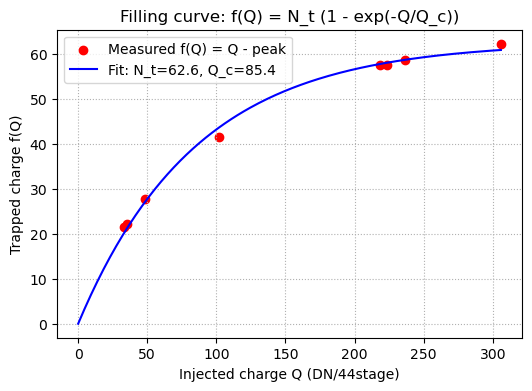

衰减因子 exp(-1/τ) = 0.3708  ->  τ = 1.008 帧


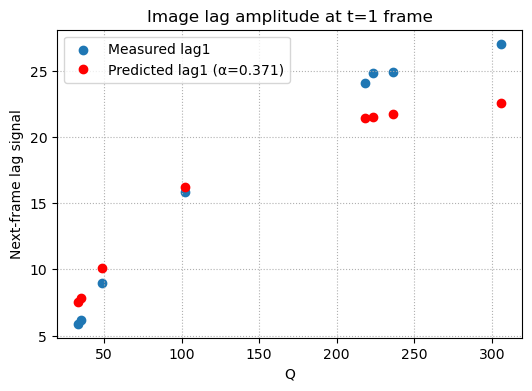


模型参数总结:
  N_t = 62.63  (陷阱饱和容量，单位同 Q)
  Q_c = 85.40  (饱和特性参数)
  τ   = 1.008 帧 (释放时间常数)


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==================== 数据录入 ====================
# 假设第一列是 Q，第二列是峰值 (peak)，第三列是次强值 (lag1)
data = np.array([
    [33.32, 11.79, 5.89],
    [35.28, 13.19, 6.14],
    [48.71, 20.86, 9.00],
    [101.98, 60.36, 15.86],
    [218.43, 160.95, 24.08],
    [223.47, 166.01, 24.84],
    [236.24, 177.66, 24.91],
    [305.86, 243.58, 27.03],
])

Q = data[:, 0]          # 注入电荷量
peak = data[:, 1]       # 本帧峰值响应
lag1 = data[:, 2]       # 下一帧的滞后信号

# 根据模型：peak = Q - f(Q)  =>  f(Q) = Q - peak
f_Q = Q - peak

# 检查是否有负值（物理上不应该，若出现则可能是测量噪声）
if np.any(f_Q < 0):
    print("警告：某些点 f(Q) 为负，将用 0 替代")
    f_Q = np.maximum(f_Q, 0)

# ==================== 拟合 f(Q) = N_t * (1 - exp(-Q/Q_c)) ====================
def trapping_model(Q, N_t, Q_c):
    return N_t * (1 - np.exp(-Q / Q_c))

# 初始猜测
p0 = [f_Q.max(), np.median(Q)]   # N_t 约最大俘获量, Q_c 约中位数
params, cov = curve_fit(trapping_model, Q, f_Q, p0=p0, bounds=([0, 0], [np.inf, np.inf]))
N_t, Q_c = params
print(f"拟合结果: N_t = {N_t:.2f}, Q_c = {Q_c:.2f}")

# 计算拟合的 f(Q) 曲线
Q_fit = np.linspace(0, Q.max(), 200)
f_fit = trapping_model(Q_fit, N_t, Q_c)

# 绘图
plt.figure(figsize=(6,4))
plt.scatter(Q, f_Q, label='Measured f(Q) = Q - peak', color='red')
plt.plot(Q_fit, f_fit, 'b-', label=f'Fit: N_t={N_t:.1f}, Q_c={Q_c:.1f}')
plt.xlabel('Injected charge Q (DN/44stage)')
plt.ylabel('Trapped charge f(Q)')
plt.title('Filling curve: f(Q) = N_t (1 - exp(-Q/Q_c))')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# ==================== 估计释放时间常数 tau ====================
# 模型：lag1 = f(Q) * exp(-1/tau)   =>   exp(-1/tau) = lag1 / f(Q)
# 取所有有效点（f(Q)>0）的平均值
valid = f_Q > 0
alpha = lag1[valid] / f_Q[valid]   # 应等于 exp(-1/tau)
alpha_mean = np.mean(alpha)
tau = -1 / np.log(alpha_mean) if alpha_mean > 0 else np.inf
print(f"衰减因子 exp(-1/τ) = {alpha_mean:.4f}  ->  τ = {tau:.3f} 帧")

# 可选：验证拟合后的滞后预测
plt.figure(figsize=(6,4))
# 用拟合的 f(Q) 预测 lag1
f_Q_fit = trapping_model(Q, N_t, Q_c)
lag1_pred = f_Q_fit * alpha_mean
plt.scatter(Q, lag1, label='Measured lag1')
plt.plot(Q, lag1_pred, 'ro', label=f'Predicted lag1 (α={alpha_mean:.3f})')
plt.xlabel('Q')
plt.ylabel('Next-frame lag signal')
plt.title('Image lag amplitude at t=1 frame')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# ==================== 打印总结 ====================
print("\n模型参数总结:")
print(f"  N_t = {N_t:.2f}  (陷阱饱和容量，单位同 Q)")
print(f"  Q_c = {Q_c:.2f}  (饱和特性参数)")
print(f"  τ   = {tau:.3f} 帧 (释放时间常数)")